<a href="https://colab.research.google.com/github/shweta714/Car-Price_Prediction_Model/blob/main/Car_Price_Prediction_AIML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/car_data.csv')

In [ ]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [ ]:
# Check the number of rows and columns
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 4340
Number of columns: 8


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [ ]:
df.describe()

,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


In [ ]:
df.isnull().sum()

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0


In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 763


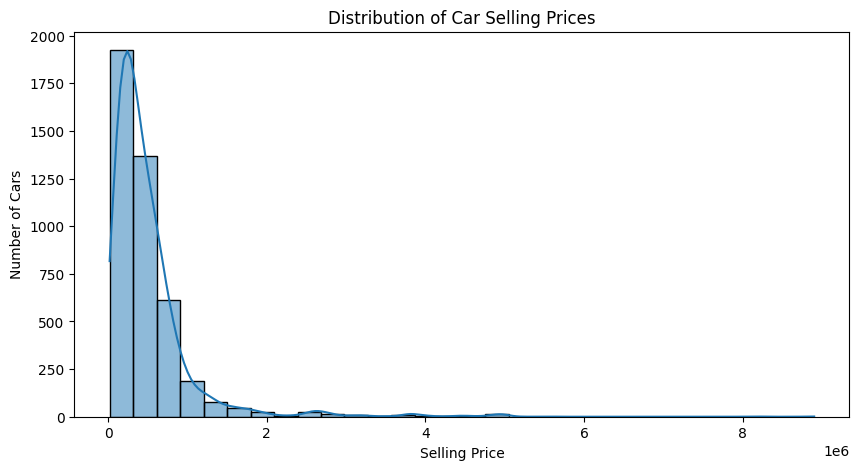

In [ ]:
plt.figure(figsize=(10, 5))

sns.histplot(df['selling_price'], bins=30, kde=True)

plt.title('Distribution of Car Selling Prices')
plt.xlabel('Selling Price')
plt.ylabel('Number of Cars')

plt.show()

In [ ]:
from datetime import datetime

current_year = datetime.now().year

df['car_age'] = current_year - df['year']

df[['year', 'car_age', 'selling_price']].head()

,year,car_age,selling_price
0,2007,19,60000
1,2007,19,135000
2,2012,14,600000
3,2017,9,250000
4,2014,12,450000


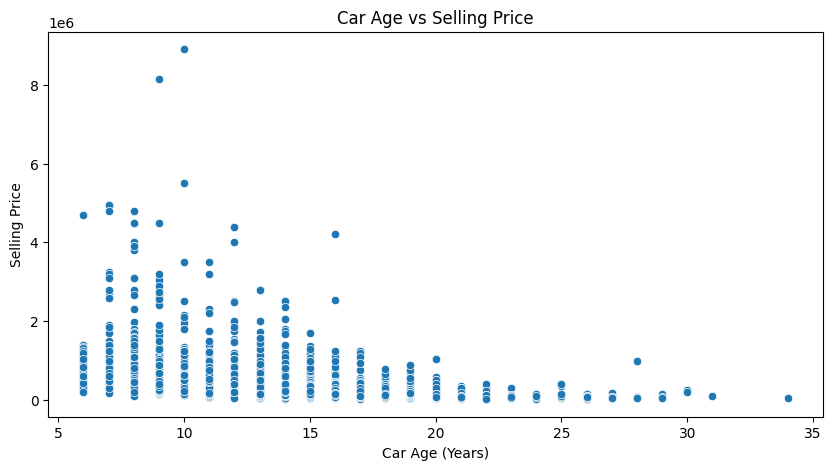

In [ ]:
plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=df,
    x='car_age',
    y='selling_price'
)

plt.title('Car Age vs Selling Price')
plt.xlabel('Car Age (Years)')
plt.ylabel('Selling Price')

plt.show()

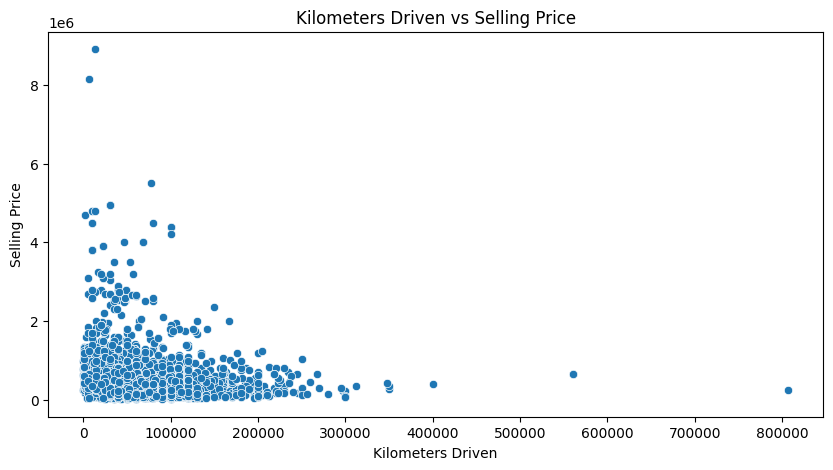

In [ ]:
plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=df,
    x='km_driven',
    y='selling_price'
)

plt.title('Kilometers Driven vs Selling Price')
plt.xlabel('Kilometers Driven')
plt.ylabel('Selling Price')

plt.show()

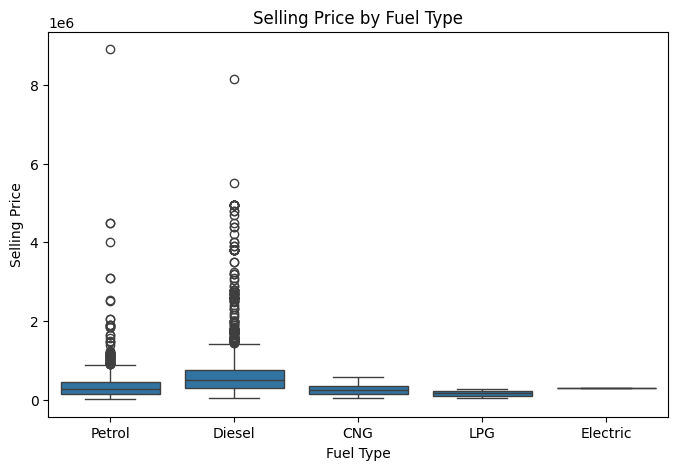

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='fuel',
    y='selling_price'
)

plt.title('Selling Price by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Selling Price')

plt.show()

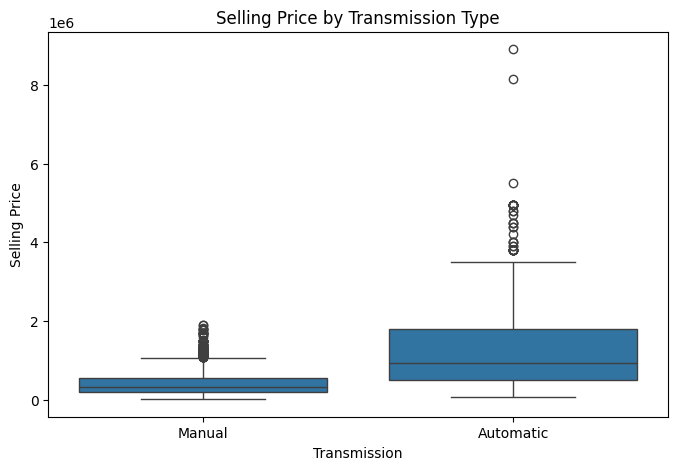

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='transmission',
    y='selling_price'
)

plt.title('Selling Price by Transmission Type')
plt.xlabel('Transmission')
plt.ylabel('Selling Price')

plt.show()

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

numeric_df.corr()

,year,selling_price,km_driven,car_age
year,1.000000,0.413922,-0.419688,-1.000000
selling_price,0.413922,1.000000,-0.192289,-0.413922
km_driven,-0.419688,-0.192289,1.000000,0.419688
car_age,-1.000000,-0.413922,0.419688,1.000000


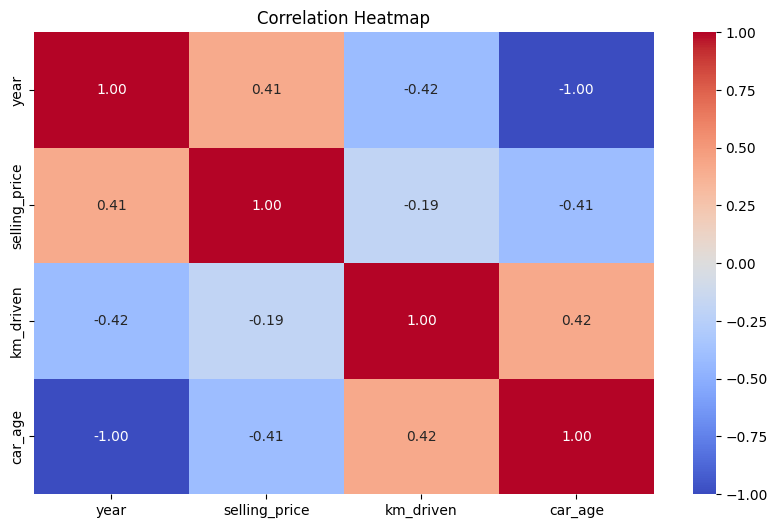

In [ ]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.show()